# Assignment 1: Introduction to Language Modeling

RNN-based autoregressive language model on Wikipedia paragraphs.

All implementation lives in `A1_skeleton.py` (tokenizer, model, trainer).
This notebook walks through the 5 parts of the assignment and contains the sanity checks + Part 5 evaluation.

## Setup

Clone the repo, install deps, download NLTK punkt.

In [1]:
# Clone the repo and cd into the assignment folder.
# If you're running this notebook from inside the cloned repo already,
# you can skip this cell.
!git clone https://github.com/dmw1998/WASP_DL4NLP26.git 2>/dev/null || true
%cd WASP_DL4NLP26/Assignments/A1/a1_1
!ls

/content/WASP_DL4NLP26/Assignments/A1/a1_1
A1_skeleton.py	assignment1.ipynb  train.txt  val.txt


In [2]:
!pip install -q datasets nltk scikit-learn matplotlib transformers accelerate

In [3]:
import os, math
import torch
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

TRAIN_FILE = 'train.txt'
VAL_FILE = 'val.txt'
assert os.path.exists(TRAIN_FILE), f'{TRAIN_FILE} not found in {os.getcwd()}'
assert os.path.exists(VAL_FILE), f'{VAL_FILE} not found in {os.getcwd()}'

CUDA available: True
GPU: Tesla T4


## Part 1: Tokenization

### Task 1.1 + 1.2 — build vocabulary

`build_tokenizer` reads the training file line by line, uses NLTK `word_tokenize` + lowercase, and keeps the most frequent words up to `max_voc_size`. The 4 special tokens `<PAD>`, `<UNK>`, `<BOS>`, `<EOS>` occupy ids 0–3.

In [4]:
from A1_skeleton import (
    build_tokenizer, A1Tokenizer, lowercase_tokenizer,
    A1RNNModelConfig, A1RNNModel,
    A1Trainer,
)

MAX_VOC_SIZE = 10000
MODEL_MAX_LENGTH = 128

tokenizer = build_tokenizer(
    train_file=TRAIN_FILE,
    tokenize_fun=lowercase_tokenizer,
    max_voc_size=MAX_VOC_SIZE,
    model_max_length=MODEL_MAX_LENGTH,
)

print('vocab size:', len(tokenizer))
print('pad_token_id:', tokenizer.pad_token_id)
print('first 10 entries:', list(tokenizer.str_to_int.items())[:10])

vocab size: 10000
pad_token_id: 0
first 10 entries: [('<PAD>', 0), ('<UNK>', 1), ('<BOS>', 2), ('<EOS>', 3), ('the', 4), (',', 5), ('.', 6), ('of', 7), ('and', 8), ('in', 9)]


In [5]:
# Sanity checks for Task 1.2
assert len(tokenizer) <= MAX_VOC_SIZE, 'vocab is larger than the cap'
for tok in ['<PAD>', '<UNK>', '<BOS>', '<EOS>']:
    assert tok in tokenizer.str_to_int, f'{tok} missing from vocab'

# Common words should be present; rare words should typically not be.
for w in ['the', 'and', 'of']:
    assert w in tokenizer.str_to_int, f'common word {w!r} should be in vocab'
for w in ['cuboidal', 'epiglottis']:
    if w not in tokenizer.str_to_int:
        print(f'OK: rare word {w!r} not in vocab')

# Round-trip: word -> int -> word
i = tokenizer.str_to_int['the']
assert tokenizer.int_to_str[i] == 'the'
print('all sanity checks passed')

OK: rare word 'cuboidal' not in vocab
OK: rare word 'epiglottis' not in vocab
all sanity checks passed


### Task 1.3 — A1Tokenizer.__call__

Verify the tokenizer handles a batch of differently-sized inputs, pads on the right, and returns a PyTorch tensor.

In [6]:
test_texts = ['This is a test.', 'Another test.']
enc = tokenizer(test_texts, return_tensors='pt', padding=True, truncation=True)
print(enc)

# Convert ids back to words for visual confirmation.
for i, ids in enumerate(enc['input_ids']):
    words = [tokenizer.int_to_str[int(x)] for x in ids]
    print(f'row {i}:', words)

{'input_ids': tensor([[  2,  35,  14,  11, 965,   6,   3],
        [  2, 153, 965,   6,   3,   0,   0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 0, 0]])}
row 0: ['<BOS>', 'this', 'is', 'a', 'test', '.', '<EOS>']
row 1: ['<BOS>', 'another', 'test', '.', '<EOS>', '<PAD>', '<PAD>']


In [7]:
# Save and reload the tokenizer.
tokenizer.save('a1_tokenizer.pkl')
reloaded = A1Tokenizer.from_file('a1_tokenizer.pkl')
assert len(reloaded) == len(tokenizer)
print('tokenizer save/load OK')

tokenizer save/load OK


## Part 2: load datasets, quick batching demo

(Not required in the submission, just sanity-checks the data pipeline.)

In [8]:
from datasets import load_dataset

dataset = load_dataset(
    'text',
    data_files={'train': TRAIN_FILE, 'val': VAL_FILE},
)
dataset = dataset.filter(lambda x: x['text'].strip() != '')

print('train size:', len(dataset['train']))
print('val size:  ', len(dataset['val']))
print('\nexample paragraph:')
print(dataset['train'][8]['text'][:300])

Generating train split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

Filter:   0%|          | 0/294118 [00:00<?, ? examples/s]

Filter:   0%|          | 0/35748 [00:00<?, ? examples/s]

train size: 147059
val size:   17874

example paragraph:
The term "anatomy" is commonly taken to refer to human anatomy.  However, substantially the same structures and tissues are found throughout the rest of the animal kingdom and the term also includes the anatomy of other animals.  The term "zootomy" is also sometimes used to specifically refer to ani


In [9]:
# DataLoader demo: peek at the first batch.
from torch.utils.data import DataLoader
demo_loader = DataLoader(dataset['train'], batch_size=4, shuffle=False)
for batch in demo_loader:
    print('keys:', list(batch.keys()))
    print('first text:', batch['text'][0][:150])
    break

keys: ['text']
first text: Anatomy


## Part 3: define the RNN language model

### Task 3.1 + 3.2

Architecture: embedding → LSTM → unembedding. The loss (computed in `forward` when `labels` is given) uses a shift-by-one trick: at position *i* the model is trained to predict the token at position *i+1*.

In [10]:
config = A1RNNModelConfig(
    vocab_size=len(tokenizer),
    embedding_size=128,
    hidden_size=256,
)
model = A1RNNModel(config)
n_params = sum(p.numel() for p in model.parameters())
print(f'model parameters: {n_params:,}')
print(model)

model parameters: 4,245,264
A1RNNModel(
  (embedding): Embedding(10000, 128)
  (rnn): LSTM(128, 256, batch_first=True)
  (unembedding): Linear(in_features=256, out_features=10000, bias=True)
  (loss_func): CrossEntropyLoss()
)


In [11]:
# Sanity check: a 1 x N input should produce a 1 x N x V logits tensor.
N = 7
dummy = torch.randint(0, len(tokenizer), (1, N))
with torch.no_grad():
    out = model(dummy)
print('logits shape:', out.logits.shape,
      f'(expected: 1 x {N} x {len(tokenizer)})')
assert out.logits.shape == (1, N, len(tokenizer))

# With labels, the model also returns a loss.
out = model(dummy, labels=dummy)
print('loss with labels (random init):', out.loss.item())

logits shape: torch.Size([1, 7, 10000]) (expected: 1 x 7 x 10000)
loss with labels (random init): 9.213833808898926


## Part 4: train the model

Uses HuggingFace `TrainingArguments`. The skeleton requires `optim='adamw_torch'` and `eval_strategy='epoch'`.

Set `dev_mode = True` first to make sure the pipeline runs end-to-end on a tiny subset (~1 minute on GPU). Then switch to `dev_mode = False` for the real run.

In [16]:
from torch.utils.data import Subset
from transformers import TrainingArguments

dev_mode = False

if dev_mode:
    train_ds = Subset(dataset['train'], range(1000))
    val_ds = Subset(dataset['val'], range(200))
    epochs = 1
else:
    train_ds = dataset['train']
    val_ds = dataset['val']
    epochs = 3

args = TrainingArguments(
    output_dir='trainer_output',
    optim='adamw_torch',
    eval_strategy='epoch',
    learning_rate=1e-3,
    num_train_epochs=epochs,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128,
    logging_steps=100,
    save_strategy='no',     # we save manually at the end of training
    report_to='none',
    use_cpu=False,
)
# Fix for AttributeError: 'TrainingArguments' object has no attribute 'no_cuda'
# The A1Trainer expects a 'no_cuda' attribute, which can be derived from 'use_cpu'.
args.no_cuda = args.use_cpu

# Fix for TypeError: A1RNNModelConfig.__init__() missing 1 required positional argument: 'vocab_size'
# The transformers library's save_pretrained method attempts to instantiate the config class without arguments.
# Setting has_no_defaults_at_init to True prevents this.
model.config.has_no_defaults_at_init = True

trainer = A1Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
)
trainer.train()

Device: cuda
Epoch 1 step 100 avg_loss 5.5006
Epoch 1 step 200 avg_loss 5.3755
Epoch 1 step 300 avg_loss 5.2834
Epoch 1 step 400 avg_loss 5.1889
Epoch 1 step 500 avg_loss 5.1065
Epoch 1 step 600 avg_loss 5.0786
Epoch 1 step 700 avg_loss 5.0167
Epoch 1 step 800 avg_loss 4.9930
Epoch 1 step 900 avg_loss 4.9465
Epoch 1 step 1000 avg_loss 4.9184
Epoch 1 step 1100 avg_loss 4.8867
Epoch 1 step 1200 avg_loss 4.8618
Epoch 1 step 1300 avg_loss 4.8349
Epoch 1 step 1400 avg_loss 4.8108
Epoch 1 step 1500 avg_loss 4.7807
Epoch 1 step 1600 avg_loss 4.7700
Epoch 1 step 1700 avg_loss 4.7535
Epoch 1 step 1800 avg_loss 4.7332
Epoch 1 step 1900 avg_loss 4.7068
Epoch 1 step 2000 avg_loss 4.6941
Epoch 1 step 2100 avg_loss 4.6655
Epoch 1 step 2200 avg_loss 4.6646
Validation loss after epoch 1: 4.5977  ppl: 99.25
Epoch 2 step 100 avg_loss 4.5914
Epoch 2 step 200 avg_loss 4.6001
Epoch 2 step 300 avg_loss 4.5764
Epoch 2 step 400 avg_loss 4.5597
Epoch 2 step 500 avg_loss 4.5572
Epoch 2 step 600 avg_loss 4.5485


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Part 5: Evaluation

### Task 5.1 — predict the next word

Encode a prompt, look at the logits one position *before* the `<EOS>` token (since the tokenizer always appends `<EOS>`), then read off the top-k predictions.

In [17]:
def predict_next(model, tokenizer, prompt, k=5):
    device = next(model.parameters()).device
    model.eval()
    enc = tokenizer(prompt, return_tensors='pt')
    input_ids = enc['input_ids'].to(device)
    with torch.no_grad():
        out = model(input_ids)
    # Position -2 is the last *real* token (position -1 is <EOS>).
    logits = out.logits[0, -2]
    topk = torch.topk(logits, k)
    return [
        (tokenizer.int_to_str[i.item()], s.item())
        for i, s in zip(topk.indices, topk.values)
    ]

for prompt in [
    'She lives in San',
    'The president of the United',
    'He played the guitar and',
    'The capital of Sweden is',
]:
    print(f'prompt: {prompt!r}')
    for word, score in predict_next(model, tokenizer, prompt):
        print(f'  {word:20s} {score:.3f}')
    print()

prompt: 'She lives in San'
  francisco            8.960
  diego                8.502
  <UNK>                7.433
  antonio              6.350
  suu                  5.949

prompt: 'The president of the United'
  states               10.397
  kingdom              9.479
  nations              8.132
  methodist            5.775
  <UNK>                5.738

prompt: 'He played the guitar and'
  <UNK>                5.031
  the                  3.949
  his                  3.492
  he                   3.395
  was                  3.312

prompt: 'The capital of Sweden is'
  the                  6.466
  a                    6.061
  <UNK>                5.863
  located              5.019
  also                 4.752



### Task 5.2 — perplexity on the validation set

Perplexity = exp(mean cross-entropy loss over all non-padding tokens). A well-trained model on this dataset should land in the 200–300 range; >700 typically indicates a bug.

In [18]:
# Token-weighted mean CE loss over the validation set.
from torch.utils.data import DataLoader

def collate(batch):
    texts = [ex['text'] for ex in batch]
    enc = tokenizer(texts, truncation=True, padding=True, return_tensors='pt')
    input_ids = enc['input_ids']
    labels = input_ids.clone()
    labels[labels == tokenizer.pad_token_id] = -100
    return {'input_ids': input_ids, 'labels': labels}

val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, collate_fn=collate)

device = next(model.parameters()).device
model.eval()
total_loss = 0.0
total_tokens = 0
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        out = model(input_ids, labels=labels)
        # The shift drops one position per row, so token count is computed
        # against shifted labels (positions 1..T-1).
        n = int((labels[:, 1:] != -100).sum().item())
        total_loss += out.loss.item() * n
        total_tokens += n

mean_ce = total_loss / total_tokens
ppl = math.exp(mean_ce)
print(f'mean cross-entropy: {mean_ce:.4f}')
print(f'perplexity:         {ppl:.2f}')

mean cross-entropy: 4.3279
perplexity:         75.79


### Task 5.3 — inspect learned word embeddings

For a well-trained embedding, nearest neighbors of a word should be semantically related.

In [19]:
from torch import nn

def nearest_neighbors(emb, voc, inv_voc, word, n_neighbors=5):
    if word not in voc:
        print(f'{word!r} not in vocab')
        return []
    test_emb = emb.weight[voc[word]]
    sim = nn.CosineSimilarity(dim=1)(test_emb, emb.weight)
    top = sim.topk(n_neighbors + 1)
    # Skip position 0: that's the query word itself.
    return [
        (inv_voc[ix.item()], cos.item())
        for ix, cos in zip(top.indices[1:], top.values[1:])
    ]

# Move embedding to CPU for the cosine sim computation.
emb = model.embedding.cpu()
for w in ['sweden', 'king', 'three', 'london', 'small', 'paris']:
    print(f'neighbors of {w!r}:')
    for nbr, score in nearest_neighbors(
        emb, tokenizer.str_to_int, tokenizer.int_to_str, w
    ):
        print(f'  {nbr:20s} {score:.3f}')
    print()

neighbors of 'sweden':
  baku                 0.351
  queens               0.343
  interact             0.334
  james                0.314
  boats                0.312

neighbors of 'king':
  cameron              0.316
  abbot                0.300
  philosopher          0.290
  prince               0.288
  manuel               0.286

neighbors of 'three':
  six                  0.397
  proportion           0.383
  five                 0.335
  sixteen              0.308
  two                  0.305

neighbors of 'london':
  narrow               0.344
  australia            0.312
  florence             0.299
  fashion              0.291
  gear                 0.285

neighbors of 'small':
  slight               0.297
  historical           0.293
  simpler              0.293
  incoming             0.290
  usa                  0.290

neighbors of 'paris':
  proceedings          0.327
  engine               0.320
  achievements         0.314
  1919                 0.310
  apparent           

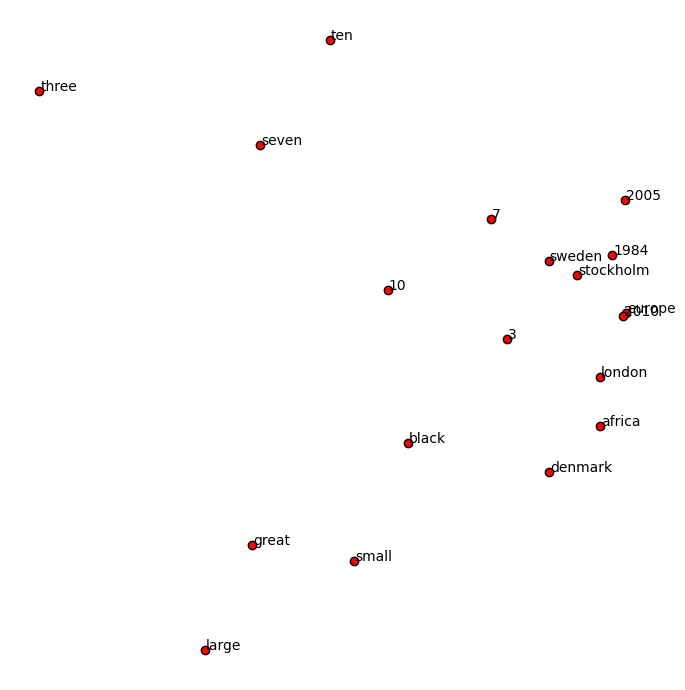

In [20]:
# Optional: 2D PCA scatterplot of selected embeddings.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

def plot_embeddings_pca(emb, voc, words):
    words = [w for w in words if w in voc]
    vecs = np.vstack([
        emb.weight[voc[w]].detach().cpu().numpy() for w in words
    ])
    vecs -= vecs.mean(axis=0)
    twodim = TruncatedSVD(n_components=2).fit_transform(vecs)
    plt.figure(figsize=(7, 7))
    plt.scatter(twodim[:, 0], twodim[:, 1], c='r', edgecolors='k')
    for w, (x, y) in zip(words, twodim):
        plt.text(x + 0.02, y, w)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_embeddings_pca(
    emb,
    tokenizer.str_to_int,
    ['sweden', 'denmark', 'europe', 'africa', 'london', 'stockholm',
     'large', 'small', 'great', 'black',
     '3', '7', '10', 'seven', 'three', 'ten',
     '1984', '2005', '2010'],
)

## Reloading a trained model later

```python
from A1_skeleton import A1RNNModel, A1Tokenizer
tokenizer = A1Tokenizer.from_file('a1_tokenizer.pkl')
model = A1RNNModel.from_pretrained('trainer_output')
```